In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/maldev08/amazon-ml-challenge-dataset/student_resource/Documentation_template.md
/kaggle/input/datasets/maldev08/amazon-ml-challenge-dataset/student_resource/README.md
/kaggle/input/datasets/maldev08/amazon-ml-challenge-dataset/student_resource/utils/validate_submission.py
/kaggle/input/datasets/maldev08/amazon-ml-challenge-dataset/student_resource/dataset/test/test_source2.tsv
/kaggle/input/datasets/maldev08/amazon-ml-challenge-dataset/student_resource/dataset/test/test_source3.tsv
/kaggle/input/datasets/maldev08/amazon-ml-challenge-dataset/student_resource/dataset/test/test_source1.tsv
/kaggle/input/datasets/maldev08/amazon-ml-challenge-dataset/student_resource/dataset/train/train_ground_truth.tsv
/kaggle/input/datasets/maldev08/amazon-ml-challenge-dataset/student_resource/dataset/train/train_source3.tsv
/kaggle/input/datasets/maldev08/amazon-ml-challenge-dataset/student_resource/dataset/train/train_source2.tsv
/kaggle/input/datasets/maldev08/amazon-ml-challenge

# Importing Dependencies

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# Data Ingestion

In [3]:
# Define the base paths based on the Kaggle input directory structure
train_dir = "/kaggle/input/datasets/maldev08/amazon-ml-challenge-dataset/student_resource/dataset/train"
test_dir = "/kaggle/input/datasets/maldev08/amazon-ml-challenge-dataset/student_resource/dataset/test"

print("Loading training data...")

# Use engine='pyarrow' for memory efficiency and speed on large datasets
train_s1 = pd.read_csv(f"{train_dir}/train_source1.tsv", sep="\t", engine="pyarrow")
train_s2 = pd.read_csv(f"{train_dir}/train_source2.tsv", sep="\t", engine="pyarrow")
train_s3 = pd.read_csv(f"{train_dir}/train_source3.tsv", sep="\t", engine="pyarrow")
ground_truth = pd.read_csv(f"{train_dir}/train_ground_truth.tsv", sep="\t", engine="pyarrow")

print(f"Train Source 1 Shape: {train_s1.shape}")
print(f"Train Source 2 Shape: {train_s2.shape}")
print(f"Train Source 3 Shape: {train_s3.shape}")
print(f"Ground Truth Shape: {ground_truth.shape}")

Loading training data...
Train Source 1 Shape: (2206821, 4)
Train Source 2 Shape: (5034616, 4)
Train Source 3 Shape: (5285603, 4)
Ground Truth Shape: (2206821, 2)


In [4]:
test_s1 = pd.read_csv(f"{test_dir}/test_source1.tsv", sep="\t", engine="pyarrow")
test_s2 = pd.read_csv(f"{test_dir}/test_source2.tsv", sep="\t", engine="pyarrow")
test_s3 = pd.read_csv(f"{test_dir}/test_source3.tsv", sep="\t", engine="pyarrow")

In [5]:
train_s1.head(20)

,entity_id,business_name,business_address,country
0,S1-925783039,Orelee's Barbershop,"1795 Westchester Drive, High Point, NC",US
1,S1-773889195,Prime Money,"17560 Ellis Road, Tahlequah, OK",US
2,S1-377745466,B+ Retail Inc,"1712 Montebello Avenue, Phoenix, AZ",US
3,S1-133037285,Christ Chapel,"2100 Cameron Drive, Unit APARTMENT G, Dundalk, MD",US
4,S1-755362802,Prabhav Business Center,"797, Lake Town Block A, Kolkata, Howrah, West ...",India
5,S1-851869949,Custom Wealth Services LLC,"OH, Columbus, 5559 Orville Avenue",US
6,S1-785847572,Consulting Nyasa Nursing Private Limited,"2505, Tower 1, Oakwood, Runwal Greens, Mulund ...",India
7,S1-27541239,Nexus Anchor Rain,"1111 Church Street, Unit 2007, Nashville, TN",US
8,S1-629417405,Moore Bitwise Inc,"337 Oakland Avenue, Michigan City, IN",US
9,S1-22305073,Dermatology Green Medicine,"294 Meadowcreek Drive, Unit Unit 2, Village Of...",US


# Exploratory Data Analysis

### Checking Rows, Columns, Id Duplicates

Computing structural summary...
Saved summary to /kaggle/working/structural_summary.csv


,Source,Rows,Columns,Memory (MB),Unique IDs,Duplicate IDs
0,Source 1,2206821,4,67.35,2206821,0
1,Source 2,5034616,4,153.64,5034616,0
2,Source 3,5285603,4,161.30,5285603,0
3,Ground Truth,2206821,2,33.67,2206821,0


/tmp/ipykernel_58/3193451337.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=structural_summary, x="Source", y="Rows", ax=axes[0], palette="crest")
/tmp/ipykernel_58/3193451337.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=structural_summary, x="Source", y="Memory (MB)", ax=axes[1], palette="viridis")


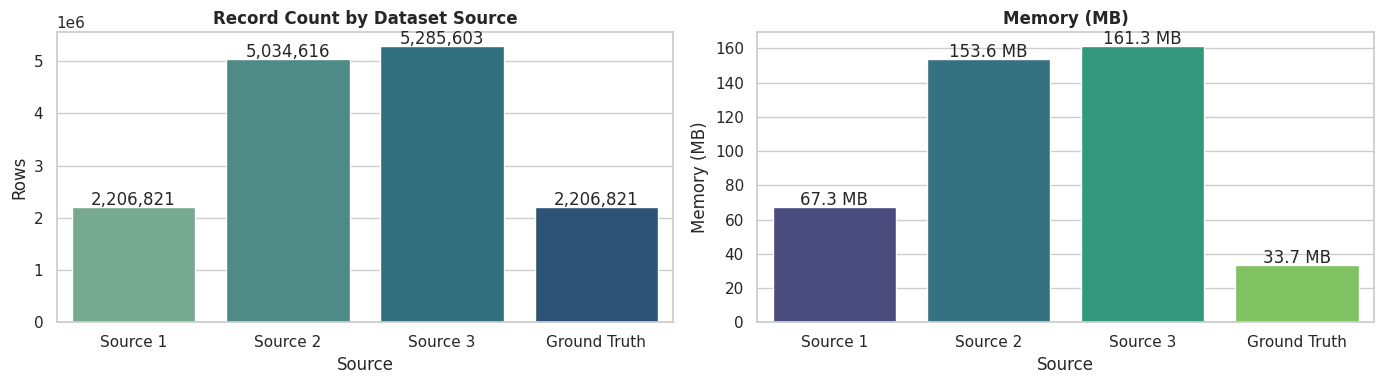

In [6]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

cache_file = "/kaggle/working/structural_summary.csv"

if os.path.exists(cache_file):
    print("Found cached summary! Loading directly from disk...")
    structural_summary = pd.read_csv(cache_file)
else:
    print("Computing structural summary...")
    sources = {
        "Source 1": train_s1,
        "Source 2": train_s2,
        "Source 3": train_s3,
        "Ground Truth": ground_truth
    }

    summary_rows = []
    for name, df in sources.items():
        # Memory usage without deep traversal (instantaneous)
        mem_mb = df.memory_usage().sum() / (1024 ** 2)
        id_col = "entity_id" if "entity_id" in df.columns else "source1_entity_id"
        
        # Check duplicate IDs (fast set/hash comparison on a single column)
        total_rows = len(df)
        unique_ids = df[id_col].nunique()
        
        summary_rows.append({
            "Source": name,
            "Rows": total_rows,
            "Columns": len(df.columns),
            "Memory (MB)": round(mem_mb, 2),
            "Unique IDs": unique_ids,
            "Duplicate IDs": total_rows - unique_ids
        })

    structural_summary = pd.DataFrame(summary_rows)
    # Persist results to disk
    structural_summary.to_csv(cache_file, index=False)
    print("Saved summary to /kaggle/working/structural_summary.csv")

display(structural_summary)

# Quick visualizations from the computed table
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=structural_summary, x="Source", y="Rows", ax=axes[0], palette="crest")
axes[0].set_title("Record Count by Dataset Source", fontweight="bold")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height()):,}", 
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha="center", va="center", xytext=(0, 5), textcoords="offset points")

sns.barplot(data=structural_summary, x="Source", y="Memory (MB)", ax=axes[1], palette="viridis")
axes[1].set_title("Memory (MB)", fontweight="bold")
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f} MB", 
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha="center", va="center", xytext=(0, 5), textcoords="offset points")

plt.tight_layout()
plt.show()

### Entity Id Validation and Missing Value Analysis

In [7]:
import time

start_time = time.time()

# ==========================================
# STEP 2.2: Entity ID Validation
# ==========================================
print("--- STEP 2.2: Entity ID Validation ---")

# 1. Verify prefixes using vectorized string matching
s1_prefix_valid = train_s1['entity_id'].str.startswith("S1-").all()
s2_prefix_valid = train_s2['entity_id'].str.startswith("S2-").all()
s3_prefix_valid = train_s3['entity_id'].str.startswith("S3-").all()

print(f"Source 1 all start with 'S1-': {s1_prefix_valid}")
print(f"Source 2 all start with 'S2-': {s2_prefix_valid}")
print(f"Source 3 all start with 'S3-': {s3_prefix_valid}")

# 2. Cross-source collision check
# Since we verified the prefixes are strictly unique per source above, 
# mathematically, zero collisions can exist between the datasets.
if s1_prefix_valid and s2_prefix_valid and s3_prefix_valid:
    print("Cross-source ID collisions: 0 (Strict prefix segregation confirmed)")

print("\n")

# ==========================================
# STEP 2.3: Missing-Value Analysis
# ==========================================
print("--- STEP 2.3: Missing-Value Analysis ---")

def analyze_missing(df, source_name):
    cols_to_check = ['business_name', 'business_address', 'country']
    results = []
    total_rows = len(df)
    
    # List of common disguised nulls
    text_null_targets = ["na", "n/a", "null", "none", "nan", "-"]
    
    for col in cols_to_check:
        # 1. True NaNs (standard missing values)
        true_na = df[col].isna().sum()
        
        # 2. Vectorized cleaning for empty/whitespace and string nulls
        # Fill NA temporarily just for the string operation to prevent type errors
        clean_series = df[col].fillna("").str.lower().str.strip()
        
        # 3. Empty strings or strings that were just whitespace
        empty_str = (clean_series == "").sum() - true_na # Subtract true_na to avoid double counting
        
        # 4. Text-based nulls
        text_nulls = clean_series.isin(text_null_targets).sum()
        
        total_missing = true_na + empty_str + text_nulls
        
        results.append({
            "Source": source_name,
            "Column": col,
            "True NaN (%)": round((true_na / total_rows) * 100, 4),
            "Empty / Whitespace (%)": round((empty_str / total_rows) * 100, 4),
            "Text Nulls (%)": round((text_nulls / total_rows) * 100, 4),
            "Total Missing (%)": round((total_missing / total_rows) * 100, 4)
        })
        
    return pd.DataFrame(results)

# Compute missing stats for all sources
missing_s1 = analyze_missing(train_s1, "Source 1")
missing_s2 = analyze_missing(train_s2, "Source 2")
missing_s3 = analyze_missing(train_s3, "Source 3")

missing_summary = pd.concat([missing_s1, missing_s2, missing_s3], ignore_index=True)

# Display the final summary table
display(missing_summary)

print(f"\nExecution Time: {round(time.time() - start_time, 2)} seconds")

--- STEP 2.2: Entity ID Validation ---
Source 1 all start with 'S1-': True
Source 2 all start with 'S2-': True
Source 3 all start with 'S3-': True
Cross-source ID collisions: 0 (Strict prefix segregation confirmed)


--- STEP 2.3: Missing-Value Analysis ---


,Source,Column,True NaN (%),Empty / Whitespace (%),Text Nulls (%),Total Missing (%)
0,Source 1,business_name,0.0000,0.0,0.0000,0.0000
1,Source 1,business_address,0.0000,0.0,0.0000,0.0000
2,Source 1,country,0.0000,0.0,0.0000,0.0000
3,Source 2,business_name,0.0000,0.0,0.0001,0.0001
4,Source 2,business_address,3.3561,0.0,0.0000,3.3561
5,Source 2,country,0.0000,0.0,0.0000,0.0000
6,Source 3,business_name,0.0002,0.0,0.0001,0.0003
7,Source 3,business_address,3.3282,0.0,0.0000,3.3282
8,Source 3,country,0.0000,0.0,0.0000,0.0000



Execution Time: 32.2 seconds


### Length Distribution

--- STEP 2.4: Length & Token Distributions (5% Sample) ---


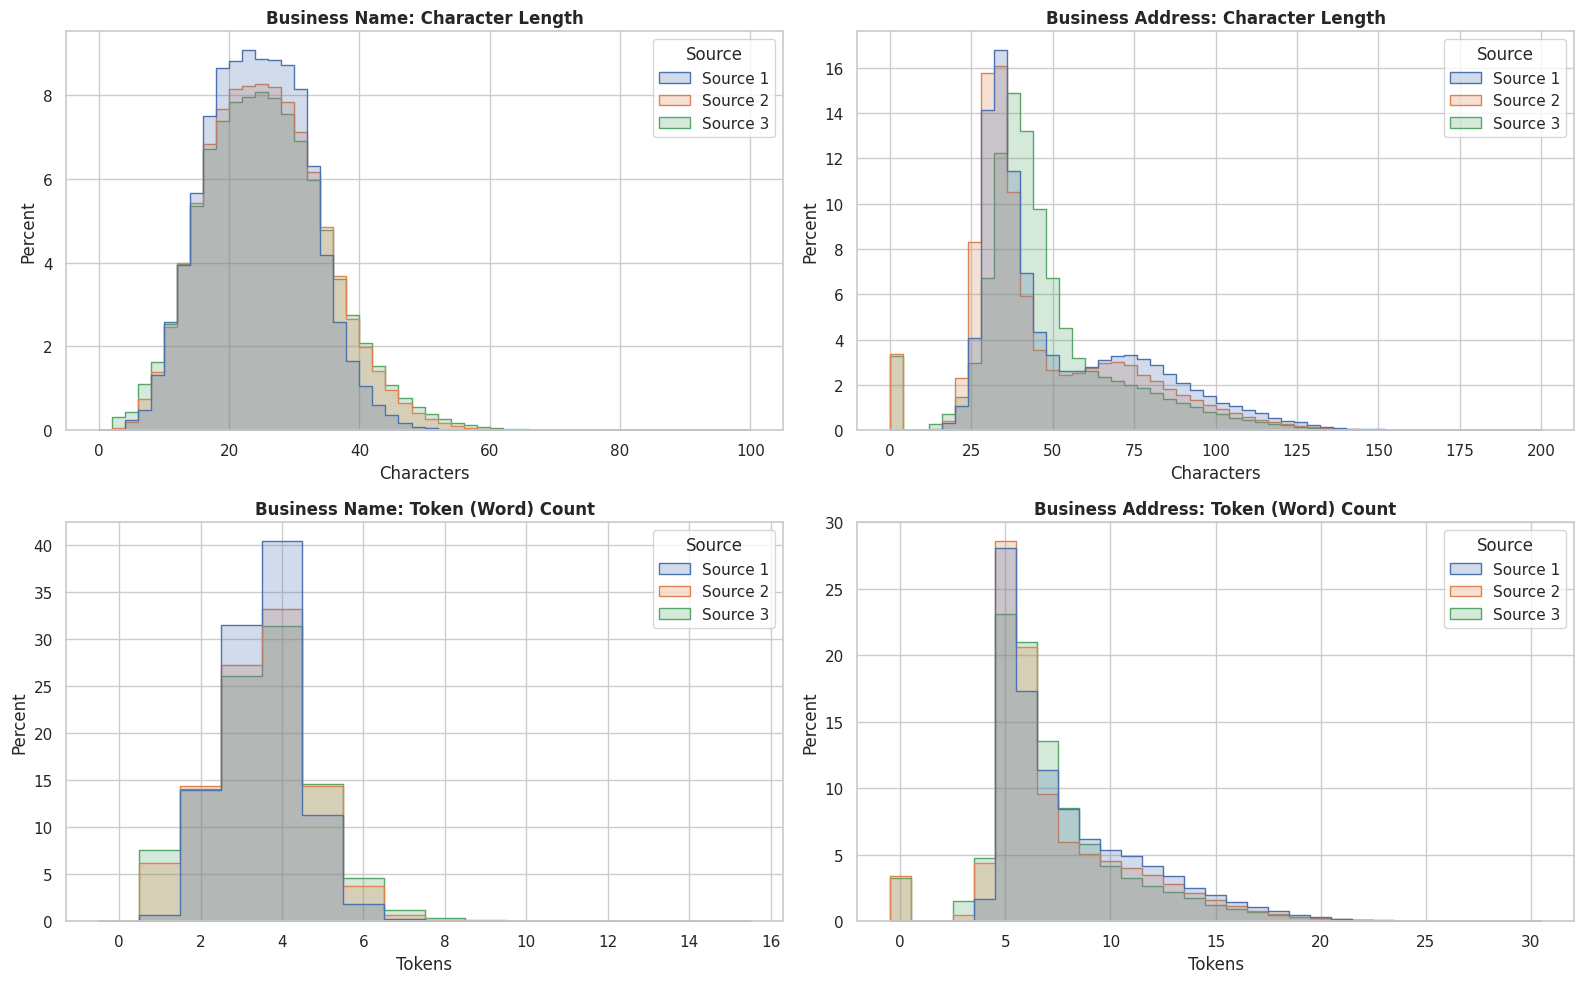


99th Percentile Lengths (to detect extreme outliers):

Source 1:
  Name: 42 chars, 6 tokens
  Addr: 124 chars, 19 tokens

Source 2:
  Name: 48 chars, 6 tokens
  Addr: 118 chars, 18 tokens

Source 3:
  Name: 50 chars, 7 tokens
  Addr: 115 chars, 18 tokens


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("--- STEP 2.4: Length & Token Distributions (5% Sample) ---")

# Take a 5% sample for instant computation and plotting
np.random.seed(42)
s1_sample = train_s1.sample(frac=0.05).copy()
s2_sample = train_s2.sample(frac=0.05).copy()
s3_sample = train_s3.sample(frac=0.05).copy()

samples = {"Source 1": s1_sample, "Source 2": s2_sample, "Source 3": s3_sample}

for name, df in samples.items():
    # Fill NaNs temporarily as empty strings to calculate lengths
    names = df['business_name'].fillna("")
    addresses = df['business_address'].fillna("")
    
    # Character Lengths
    df['name_char_len'] = names.str.len()
    df['addr_char_len'] = addresses.str.len()
    
    # Token (Word) Counts
    df['name_token_count'] = names.str.split().str.len()
    df['addr_token_count'] = addresses.str.split().str.len()

# Combine samples for plotting
combined_sample = pd.concat([
    s1_sample.assign(Source="Source 1"),
    s2_sample.assign(Source="Source 2"),
    s3_sample.assign(Source="Source 3")
])

# Plotting
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.set_theme(style="whitegrid")

# 1. Name Character Length
sns.histplot(data=combined_sample, x="name_char_len", hue="Source", bins=50, 
             binrange=(0, 100), element="step", stat="percent", common_norm=False, ax=axes[0, 0])
axes[0, 0].set_title("Business Name: Character Length", fontweight="bold")
axes[0, 0].set_xlabel("Characters")

# 2. Address Character Length
sns.histplot(data=combined_sample, x="addr_char_len", hue="Source", bins=50, 
             binrange=(0, 200), element="step", stat="percent", common_norm=False, ax=axes[0, 1])
axes[0, 1].set_title("Business Address: Character Length", fontweight="bold")
axes[0, 1].set_xlabel("Characters")

# 3. Name Token Count
sns.histplot(data=combined_sample, x="name_token_count", hue="Source", bins=20, 
             binrange=(0, 15), element="step", stat="percent", common_norm=False, ax=axes[1, 0], discrete=True)
axes[1, 0].set_title("Business Name: Token (Word) Count", fontweight="bold")
axes[1, 0].set_xlabel("Tokens")

# 4. Address Token Count
sns.histplot(data=combined_sample, x="addr_token_count", hue="Source", bins=30, 
             binrange=(0, 30), element="step", stat="percent", common_norm=False, ax=axes[1, 1], discrete=True)
axes[1, 1].set_title("Business Address: Token (Word) Count", fontweight="bold")
axes[1, 1].set_xlabel("Tokens")

plt.tight_layout()
plt.show()

# Print 99th percentiles to inform maximum sequence lengths
print("\n99th Percentile Lengths (to detect extreme outliers):")
for name, df in samples.items():
    print(f"\n{name}:")
    print(f"  Name: {df['name_char_len'].quantile(0.99):.0f} chars, {df['name_token_count'].quantile(0.99):.0f} tokens")
    print(f"  Addr: {df['addr_char_len'].quantile(0.99):.0f} chars, {df['addr_token_count'].quantile(0.99):.0f} tokens")

### Another version of the above task but on whole dataset(above it was on 5% of dataset)

--- STEP 2.4: Length Distributions (100% Population) ---


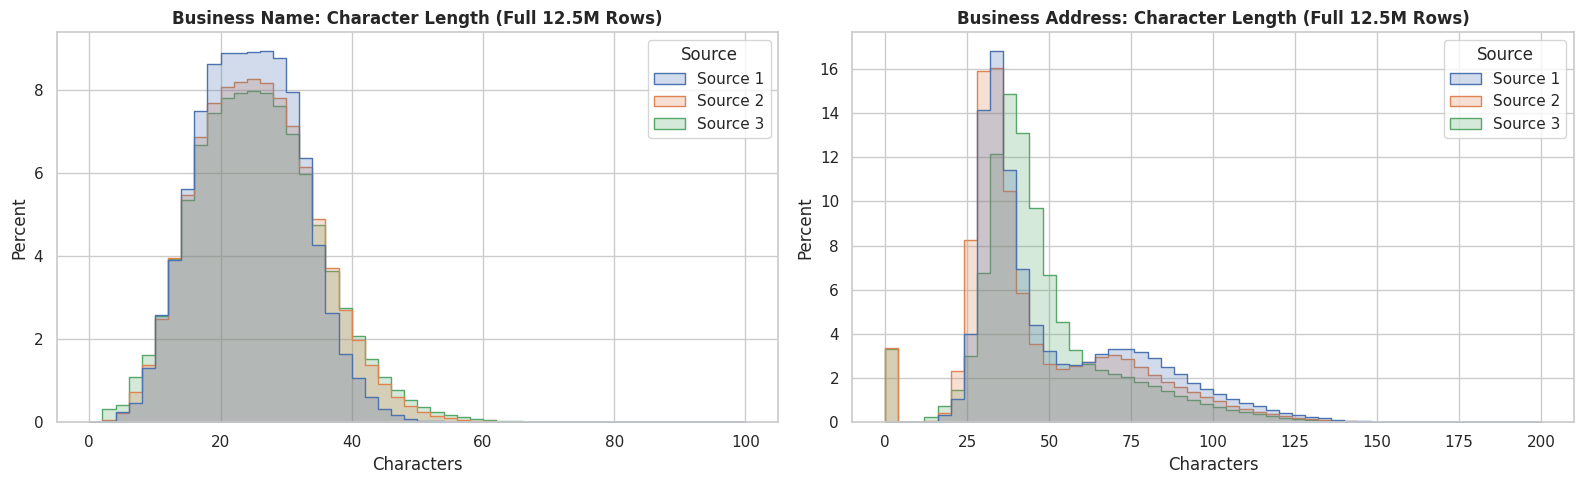


100% Population - 99th Percentile Lengths:
Source 1: Name 42 chars | Addr 124 chars
Source 2: Name 48 chars | Addr 118 chars
Source 3: Name 50 chars | Addr 115 chars


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("--- STEP 2.4: Length Distributions (100% Population) ---")

# We will calculate string length directly on the full DataFrames
# PyArrow handles .str.len() in seconds even on 5 million rows
train_s1['name_char_len'] = train_s1['business_name'].fillna("").str.len()
train_s1['addr_char_len'] = train_s1['business_address'].fillna("").str.len()

train_s2['name_char_len'] = train_s2['business_name'].fillna("").str.len()
train_s2['addr_char_len'] = train_s2['business_address'].fillna("").str.len()

train_s3['name_char_len'] = train_s3['business_name'].fillna("").str.len()
train_s3['addr_char_len'] = train_s3['business_address'].fillna("").str.len()

# Combine for plotting (using a subset of columns to save RAM)
combined_full = pd.concat([
    train_s1[['name_char_len', 'addr_char_len']].assign(Source="Source 1"),
    train_s2[['name_char_len', 'addr_char_len']].assign(Source="Source 2"),
    train_s3[['name_char_len', 'addr_char_len']].assign(Source="Source 3")
])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.set_theme(style="whitegrid")

sns.histplot(data=combined_full, x="name_char_len", hue="Source", bins=50, 
             binrange=(0, 100), element="step", stat="percent", common_norm=False, ax=axes[0])
axes[0].set_title("Business Name: Character Length (Full 12.5M Rows)", fontweight="bold")
axes[0].set_xlabel("Characters")

sns.histplot(data=combined_full, x="addr_char_len", hue="Source", bins=50, 
             binrange=(0, 200), element="step", stat="percent", common_norm=False, ax=axes[1])
axes[1].set_title("Business Address: Character Length (Full 12.5M Rows)", fontweight="bold")
axes[1].set_xlabel("Characters")

plt.tight_layout()
plt.show()

print("\n100% Population - 99th Percentile Lengths:")
print(f"Source 1: Name {train_s1['name_char_len'].quantile(0.99):.0f} chars | Addr {train_s1['addr_char_len'].quantile(0.99):.0f} chars")
print(f"Source 2: Name {train_s2['name_char_len'].quantile(0.99):.0f} chars | Addr {train_s2['addr_char_len'].quantile(0.99):.0f} chars")
print(f"Source 3: Name {train_s3['name_char_len'].quantile(0.99):.0f} chars | Addr {train_s3['addr_char_len'].quantile(0.99):.0f} chars")

## Key Insights from the Distributions

### 1. **Name Matching Strategy**

- **99%** of all business names are under **50 characters** and contain **7 tokens or fewer**.
- Since the strings are relatively short, we can safely use computationally heavier **character-level distance metrics**, such as:
  - **Levenshtein Distance**
  - **Jaro-Winkler Similarity**
- These metrics should not significantly slow down the matching pipeline for business names.

### 2. **Address Matching Strategy**

- Addresses are considerably longer, extending up to **124 characters** and **19 tokens**.
- For these longer strings, **token-based similarity metrics** are likely to be more effective and computationally efficient than character-level edit distances.
- Suitable approaches include:
  - **Jaccard Similarity**
  - **Token Set Ratio**
- These methods are particularly useful because they are less sensitive to **word order**, which can vary across different sources.

### 3. **The "Zero-Length" Spike**

- The address-length histograms show a distinct **spike at zero** for **Source 2** and **Source 3**.
- This provides a visual confirmation of the approximately **3.3% missing-address rate** identified in the previous analysis.
- Therefore, missing addresses should be explicitly handled during the matching process rather than being treated as empty but valid strings.

### Character Analysis and Country analysis

In [11]:
import pandas as pd

print("--- STEP 2.5: Character Analysis (Regex Optimized) ---")

def char_analysis(df, source_name):
    # Fill NA to prevent errors on null addresses
    names = df['business_name'].fillna("")
    addrs = df['business_address'].fillna("")
    
    # Vectorized checks using PyArrow-safe regex
    return {
        "Source": source_name,
        "Name: Not purely ASCII (%)": round(names.str.contains(r'[^\x00-\x7F]', regex=True).mean() * 100, 2),
        "Addr: Not purely ASCII (%)": round(addrs.str.contains(r'[^\x00-\x7F]', regex=True).mean() * 100, 2),
        "Name: Contains Digits (%)": round(names.str.contains(r'\d', regex=True).mean() * 100, 2),
        "Addr: Contains Digits (%)": round(addrs.str.contains(r'\d', regex=True).mean() * 100, 2),
        "Name: All Lowercase (%)": round(names.str.islower().mean() * 100, 2),
        "Name: All Uppercase (%)": round(names.str.isupper().mean() * 100, 2),
    }

char_stats = pd.DataFrame([
    char_analysis(train_s1, "Source 1"),
    char_analysis(train_s2, "Source 2"),
    char_analysis(train_s3, "Source 3")
])

display(char_stats)


print("\n--- STEP 2.6: Country EDA ---")

# Calculate country distributions across all sources
c_s1 = train_s1['country'].value_counts(normalize=True).rename('Source 1 (%)') * 100
c_s2 = train_s2['country'].value_counts(normalize=True).rename('Source 2 (%)') * 100
c_s3 = train_s3['country'].value_counts(normalize=True).rename('Source 3 (%)') * 100

country_dist = pd.concat([c_s1, c_s2, c_s3], axis=1).round(2).fillna(0)
display(country_dist)

--- STEP 2.5: Character Analysis (Regex Optimized) ---


,Source,Name: Not purely ASCII (%),Addr: Not purely ASCII (%),Name: Contains Digits (%),Addr: Contains Digits (%),Name: All Lowercase (%),Name: All Uppercase (%)
0,Source 1,0.00,0.03,1.61,96.51,0.00,0.00
1,Source 2,15.19,9.50,5.08,90.65,5.75,18.90
2,Source 3,11.48,9.02,5.12,90.80,6.25,2.96



--- STEP 2.6: Country EDA ---


,Source 1 (%),Source 2 (%),Source 3 (%)
country,,,
US,59.98,59.92,59.98
India,40.02,40.08,40.02


## Key Insights from the Vectorized Data Checks

This output reveals exactly why we ran these checks. The vectorized operations exposed **three critical data realities** that directly dictate how we should build our matching pipeline:

### 1. **The Transliteration Threat is Real**

- **Source 1** is pristine, with **0.00% non-ASCII business names**.
- However, **Source 2 and Source 3** contain a significant number of non-ASCII characters:
  - **Source 2:** 15.19%
  - **Source 3:** 11.48%
- If we attempt to match the ASCII-based **Source 1 reference** directly against Unicode names from **Source 2/Source 3**, character-level similarity algorithms may produce poor matches.
- Therefore, we should use a library such as **`unidecode`** to transliterate Unicode characters into **base ASCII** before performing feature engineering and similarity calculations.

> **Pipeline implication:** Apply transliteration consistently across all sources before generating matching features.

### 2. **Casing Inconsistencies**

- **Source 2** contains almost **19% of business names entirely in uppercase**.
- In comparison, **Source 1** contains **0.00%** fully uppercase names.
- This creates an unnecessary source-specific variation that can negatively affect string matching.

> **Pipeline implication:** Apply consistent **lowercase normalization** across all sources using `str.lower()`.

### 3. **The "Missing France" Trap**

- The training data is distributed approximately as:
  - **60% — United States**
  - **40% — India**
- **France is completely absent from the training data.**
- This is important because the hidden test set may contain French records.
- Hardcoding country-specific assumptions based only on the training distribution could therefore cause the pipeline to fail on unseen countries.

For example, we should **not** build logic that assumes addresses will always contain:

- US **ZIP codes**
- Indian **PIN codes**
- US-specific address formats
- India-specific address structures

> **Pipeline implication:** Treat the `country` field **dynamically** and design normalization, feature engineering, and matching rules to generalize across countries.

### **Overall Takeaway**

These checks establish three mandatory preprocessing requirements for the matching pipeline:

1. **Transliterate Unicode → ASCII** using `unidecode`.
2. **Normalize casing → lowercase** across all sources.
3. **Make country handling dynamic** rather than hardcoding US/India-specific rules.

### Ground Truth EDA

--- STEP 2.7 & 2.8: Ground-Truth Analysis ---


,Total True Matches,S1 Entity Count,Percentage (%)
0,0,123247,5.58
1,1,119157,5.40
2,2,375212,17.00
3,3,530841,24.05
4,4,484115,21.94
5,5,321957,14.59
6,6,164868,7.47
7,7,63968,2.90
8,8,18680,0.85
9,9,4205,0.19



--- Match Contribution by Source ---


,Source,Total Matched Entities,Contribution (%)
0,Source 2,3693619,48.36
1,Source 3,3944746,51.64


/tmp/ipykernel_58/2889119663.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=match_df, x="Total True Matches", y="S1 Entity Count", ax=axes[0], palette="flare")


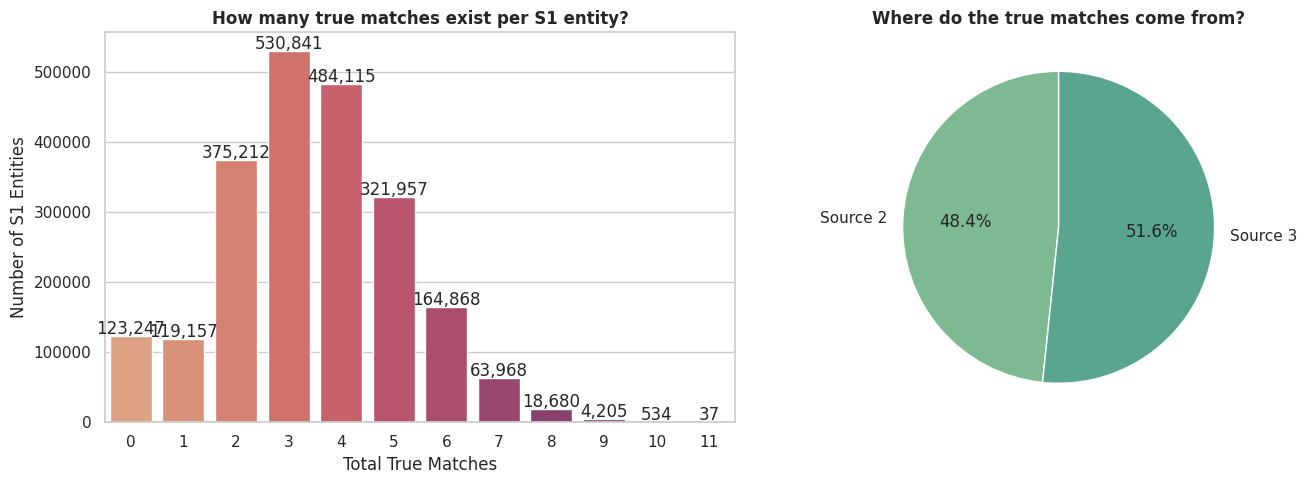

In [12]:


print("--- STEP 2.7 & 2.8: Ground-Truth Analysis ---")

# Work on a copy to avoid SettingWithCopy warnings
gt = ground_truth.copy()
gt['matched_entity_ids'] = gt['matched_entity_ids'].fillna("")

# Fast, delimiter-agnostic counting of candidate occurrences
gt['S2_matches'] = gt['matched_entity_ids'].str.count("S2-")
gt['S3_matches'] = gt['matched_entity_ids'].str.count("S3-")
gt['Total_matches'] = gt['S2_matches'] + gt['S3_matches']

# 1. Total Matches per Source 1 Entity
match_distribution = gt['Total_matches'].value_counts().sort_index()

match_df = pd.DataFrame({
    "Total True Matches": match_distribution.index,
    "S1 Entity Count": match_distribution.values,
    "Percentage (%)": (match_distribution.values / len(gt) * 100).round(2)
})
display(match_df)

# 2. Source 2 vs Source 3 Contribution
s2_total = gt['S2_matches'].sum()
s3_total = gt['S3_matches'].sum()
total_all = s2_total + s3_total

source_contribution = pd.DataFrame({
    "Source": ["Source 2", "Source 3"],
    "Total Matched Entities": [s2_total, s3_total],
    "Contribution (%)": [round(s2_total/total_all*100, 2) if total_all else 0, 
                         round(s3_total/total_all*100, 2) if total_all else 0]
})
print("\n--- Match Contribution by Source ---")
display(source_contribution)

# 3. Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_theme(style="whitegrid")

# Total Matches Barplot
sns.barplot(data=match_df, x="Total True Matches", y="S1 Entity Count", ax=axes[0], palette="flare")
axes[0].set_title("How many true matches exist per S1 entity?", fontweight="bold")
axes[0].set_ylabel("Number of S1 Entities")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height()):,}", 
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha="center", va="center", xytext=(0, 5), textcoords="offset points")

# Source Contribution Pie Chart
axes[1].pie(source_contribution['Contribution (%)'], labels=source_contribution['Source'], 
            autopct='%1.1f%%', colors=sns.color_palette("crest"), startangle=90)
axes[1].set_title("Where do the true matches come from?", fontweight="bold")

plt.tight_layout()
plt.show()

## Critical Implications for the Pipeline

### 1. **The Candidate Recall Target**

- Only **5.4%** of Source 1 entities have exactly **1 match**.
- More than **77%** of the dataset has between **2 and 5 matches**.
- The distribution peaks at **3 matches**, accounting for **24.05%** of entities.
- Therefore, a blocking strategy that retrieves only the **top 1 or 2 candidates** will severely limit candidate recall and can cause the pipeline to miss valid matches.

> **Pipeline implication:** During the blocking/candidate-generation phase, retrieve at least the **top 10–15 candidates per Source 1 entity** to maintain sufficiently high candidate recall.

### 2. **The Singleton Trap**

- Exactly **5.58%** of Source 1 entities (**123,247 records**) have **zero matches** in the candidate pools.
- The competition uses the **$F_{0.5}$ metric**, which places **twice as much weight on precision as recall**.
- Therefore, forcing a match for these entities simply because a candidate has moderate similarity can introduce a large number of **false positives** and negatively affect the final score.
- The model should be capable of predicting an **empty match** when there is insufficient evidence that a valid match exists.

> **Pipeline implication:** Introduce a **strict confidence/probability threshold** for accepting a candidate match. If no candidate exceeds this threshold, predict an empty result rather than forcing a weak match.

### 3. **Equal Source Weighting**

- **Source 3** provides slightly more matches than **Source 2**:
  - **Source 3:** 51.64%
  - **Source 2:** 48.36%
- However, the overall distribution is sufficiently balanced that neither source should be ignored or automatically considered more/less reliable.
- Source-specific reliability should instead be determined through **EDA and validation of the actual text quality and matching behavior**.

> **Pipeline implication:** Treat **Source 2 and Source 3 symmetrically during candidate generation and feature engineering**, while allowing the model to learn any source-specific differences from the data.

### **Overall Takeaway**

These findings suggest three important design requirements:

1. **High candidate recall:** Retrieve approximately **10–15 candidates per Source 1 entity** during blocking.
2. **Allow unmatched entities:** Do **not force predictions** when candidate confidence is low.
3. **Avoid source bias:** Give **Source 2 and Source 3 comparable treatment** unless validation demonstrates meaningful differences in quality.

# analyze positive pairs

In [13]:
import random

print("--- STEP 2.9: Manual Inspection of True Matches ---")

# 1. Get a list of S1 entities that have at least one match
matched_s1 = ground_truth[ground_truth['matched_entity_ids'].notna() & 
                          (ground_truth['matched_entity_ids'] != "")]

# 2. Sample 5 random S1 entities
sample_s1 = matched_s1.sample(5, random_state=42)

# 3. Create fast lookup dictionaries for printing
s1_dict = train_s1.set_index('entity_id').to_dict('index')
s2_dict = train_s2.set_index('entity_id').to_dict('index')
s3_dict = train_s3.set_index('entity_id').to_dict('index')

# 4. Print the comparisons
for _, row in sample_s1.iterrows():
    s1_id = row['source1_entity_id'] if 'source1_entity_id' in row else row['entity_id']
    matches = str(row['matched_entity_ids']).split(',')
    
    print(f"\n{'='*80}")
    print(f"REFERENCE (Source 1): {s1_id}")
    s1_data = s1_dict.get(s1_id, {})
    print(f"Name:    {s1_data.get('business_name')}")
    print(f"Address: {s1_data.get('business_address')}")
    print(f"Country: {s1_data.get('country')}")
    print("-" * 80)
    
    # Pick just one random match to display alongside it
    target_match = random.choice(matches).strip()
    source_dict = s2_dict if target_match.startswith("S2-") else s3_dict
    match_data = source_dict.get(target_match, {})
    
    print(f"TRUE MATCH ({'Source 2' if target_match.startswith('S2') else 'Source 3'}): {target_match}")
    print(f"Name:    {match_data.get('business_name')}")
    print(f"Address: {match_data.get('business_address')}")
    
print(f"{'='*80}\n")

--- STEP 2.9: Manual Inspection of True Matches ---

REFERENCE (Source 1): S1-777210964
Name:    Davis Family Office
Address: 88 Olive Circle, Lebanon, TN
Country: US
--------------------------------------------------------------------------------
TRUE MATCH (Source 2): S2-12029274
Name:    Davis Family Offie
Address: 88 OLIVE CIR, LEBANON, TN

REFERENCE (Source 1): S1-190133982
Name:    MS Consultancy Corp
Address: Shymala Appts 1St Floor Flat No. 4 Opp Ratna Hospital Sb Road In Haveli, Pune, Maharashtra
Country: India
--------------------------------------------------------------------------------
TRUE MATCH (Source 3): S3-716445195
Name:    M5  Consultancy Corp
Address: Pune, MH, Pune, Shymala Appts 1St Floor Flat No. 4 Opp Ratna Hospital Sb Road In Haveli

REFERENCE (Source 1): S1-970131671
Name:    3520 Main Road Realty Inc
Address: TX, 158 Simpson Lane, Somerset
Country: US
--------------------------------------------------------------------------------
TRUE MATCH (Source 2): S2-

### Noise Patterns and Pipeline Countermeasures

* **Typographical and OCR Errors:** We see clear misspellings ("Office" vs. "Offie") and OCR artifacts ("MS" vs. "M5"). Because these variations are slight, we must extract Levenshtein distance and Jaro-Winkler similarity features, which excel at catching 1–2 character deviations.
* **Severe Address Reordering:** Source 3 and Source 2 heavily scramble address components. "TX, 158 Simpson Lane, Somerset" becomes "SIMPSON LANE, SOMERSET, TX". A standard string comparison will score this near zero. We must use token-based metrics like Jaccard similarity and `rapidfuzz.fuzz.token_set_ratio`, which evaluate the overlap of words regardless of their order.
* **Abbreviations and Suffix Expansions:** We see "Circle" mapped to "CIR", "Drive" to "DR", "Maharashtra" to "MH", and "Pvt. Ltd." expanded to "Pvt. Limited".
* **Missing Components and Injected Artifacts:** Source 2 drops the house number "158" entirely in one example, and arbitrarily injects "##" into another. We will need a robust text preprocessing function to strip non-alphanumeric characters (excluding standard delimiters) before feature extraction.
* **Historical Geography:** "Telangana" matching with "Andhra Pradesh" is a brilliant edge case by the organizers. It requires the model to rely on the lower-level address components (like the building or street) when the state name changes due to historical redistricting.